# 05 — Music & Audio Signal Processing

**Goal**: Apply the same DSP toolkit used for physiological signals to audio.

The bridge between biosignals and audio is stronger than it seems:
- Both are 1D time series sampled at a fixed rate
- Both benefit from filtering, spectral analysis, and peak detection
- Music information retrieval (MIR) and biomedical signal processing share core methods

---

## Pipeline
1. Synthesize a musical signal (chord + harmonics)
2. FFT frequency decomposition
3. STFT spectrogram
4. Tempo / BPM estimation via onset detection
5. Compare signal energy across frequency bands

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.fft import rfft, rfftfreq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'

np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Synthesize Musical Signals

We'll build three signals:
- A single note (A4 = 440 Hz) with harmonics
- An A minor chord (A3 + C4 + E4)
- A rhythmic pulse sequence (for tempo detection)

Sample rate  : 22050 Hz
Duration     : 4.0 s
Total samples: 88,200

Notes in Am chord: A3=220.0Hz, C4=261.6Hz, E4=329.6Hz


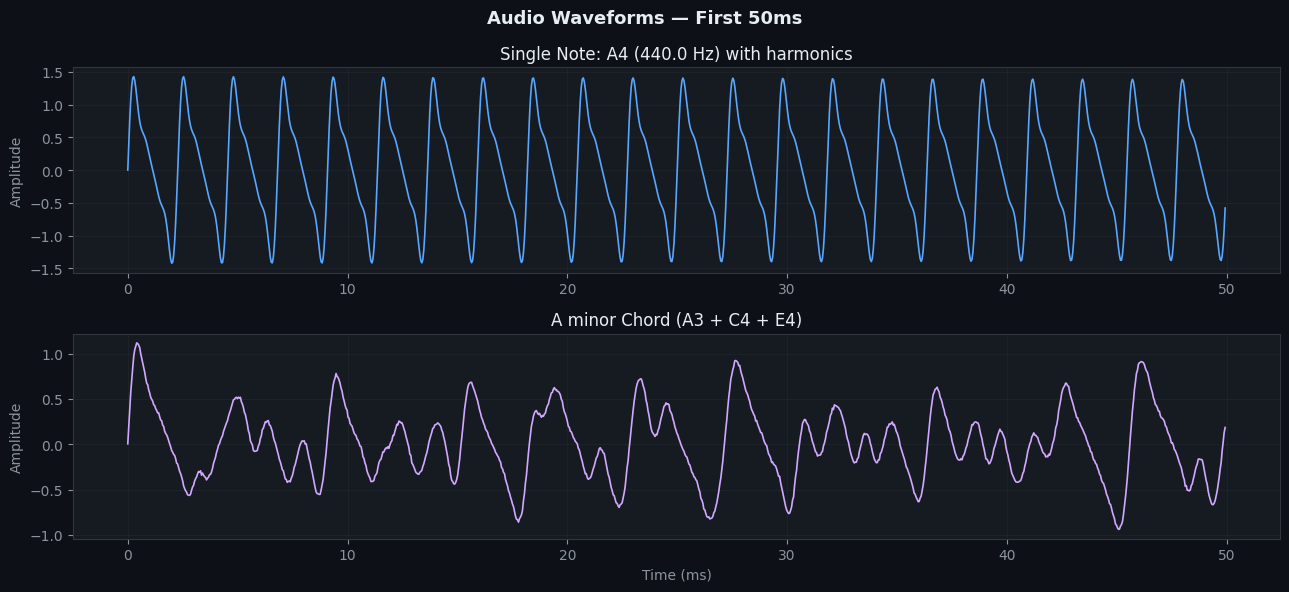

In [2]:
FS    = 22050  # standard audio sample rate (Hz)
DUR   = 4.0    # seconds
t     = np.linspace(0, DUR, int(FS * DUR), endpoint=False)

def make_note(freq, t, amplitude=1.0, decay=1.5):
    """Sinusoidal note with exponential decay and harmonics."""
    note  = amplitude       * np.sin(2 * np.pi * freq * t)
    note += amplitude * 0.5 * np.sin(2 * np.pi * freq * 2 * t)  # 2nd harmonic
    note += amplitude * 0.3 * np.sin(2 * np.pi * freq * 3 * t)  # 3rd harmonic
    note += amplitude * 0.1 * np.sin(2 * np.pi * freq * 4 * t)  # 4th harmonic
    envelope = np.exp(-t / decay)  # decay envelope
    return note * envelope

# Note frequencies (Hz)
A3 = 220.0
C4 = 261.6
E4 = 329.6
A4 = 440.0

note_a4    = make_note(A4, t, amplitude=1.0)
chord_am   = (make_note(A3, t, 1.0) +
              make_note(C4, t, 0.8) +
              make_note(E4, t, 0.6)) / 3.0

# Add slight noise
chord_am += 0.01 * np.random.normal(0, 1, len(t))

print(f'Sample rate  : {FS} Hz')
print(f'Duration     : {DUR} s')
print(f'Total samples: {len(t):,}')
print(f'\nNotes in Am chord: A3={A3}Hz, C4={C4}Hz, E4={E4}Hz')

# Plot waveform (first 50ms)
n_show = int(0.05 * FS)
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle('Audio Waveforms — First 50ms', fontsize=13, fontweight='bold')

axes[0].plot(t[:n_show]*1000, note_a4[:n_show], color=BLUE, lw=1.2)
axes[0].set_title(f'Single Note: A4 ({A4} Hz) with harmonics')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t[:n_show]*1000, chord_am[:n_show], color=PURPLE, lw=1.2)
axes[1].set_title('A minor Chord (A3 + C4 + E4)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.savefig('../figures/05_waveforms.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 2. FFT — Frequency Decomposition

The Fast Fourier Transform decomposes a signal into its constituent frequencies.
For a chord, we expect peaks at each note frequency and their harmonics.

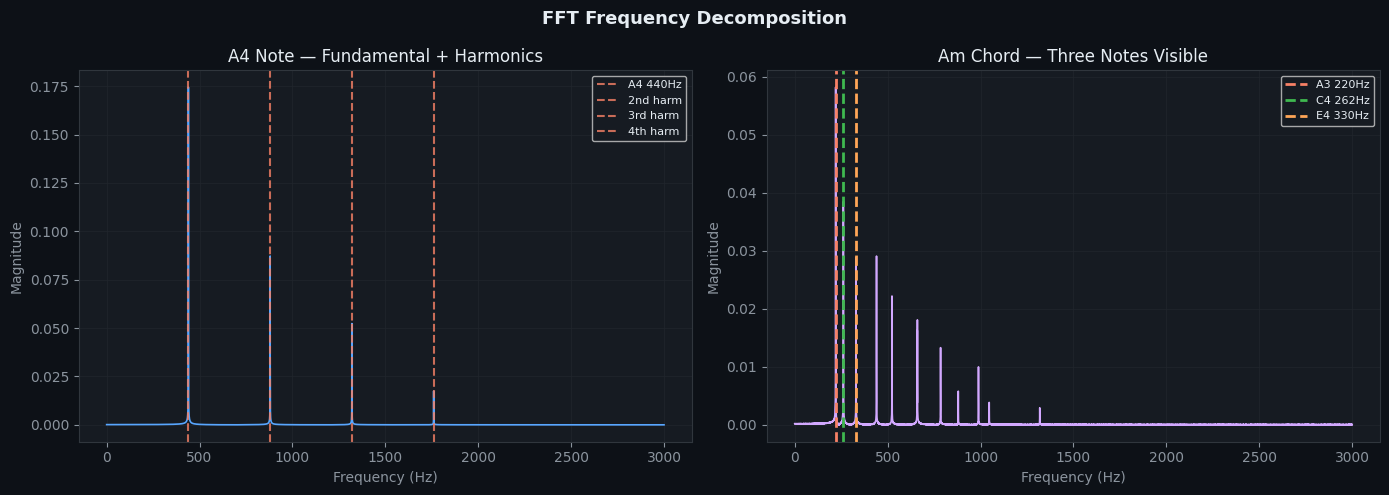

In [3]:
def compute_fft(sig, fs):
    """Compute one-sided FFT magnitude spectrum."""
    N      = len(sig)
    freqs  = rfftfreq(N, 1/fs)
    mags   = np.abs(rfft(sig)) / N
    return freqs, mags

freqs_a4, mags_a4 = compute_fft(note_a4,  FS)
freqs_am, mags_am = compute_fft(chord_am, FS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FFT Frequency Decomposition', fontsize=13, fontweight='bold')

# Single note
mask = freqs_a4 < 3000
axes[0].plot(freqs_a4[mask], mags_a4[mask], color=BLUE, lw=1.2)
for n, (harm, label) in enumerate([(A4, 'A4 440Hz'),
                                    (A4*2, '2nd harm'),
                                    (A4*3, '3rd harm'),
                                    (A4*4, '4th harm')]):
    if harm < 3000:
        axes[0].axvline(harm, color=RED, lw=1.5, ls='--', alpha=0.8, label=label)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('A4 Note — Fundamental + Harmonics')
axes[0].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

# Chord
mask2 = freqs_am < 3000
axes[1].plot(freqs_am[mask2], mags_am[mask2], color=PURPLE, lw=1.2)
note_freqs = [(A3,'A3 220Hz',RED), (C4,'C4 262Hz',GREEN), (E4,'E4 330Hz',ORANGE)]
for freq, label, color in note_freqs:
    axes[1].axvline(freq, color=color, lw=2, ls='--', label=label)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Am Chord — Three Notes Visible')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

for ax in axes:
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('../figures/05_fft.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 3. STFT Spectrogram

The Short-Time Fourier Transform (STFT) shows how the frequency content
**changes over time** — essential for music, speech, and non-stationary signals.

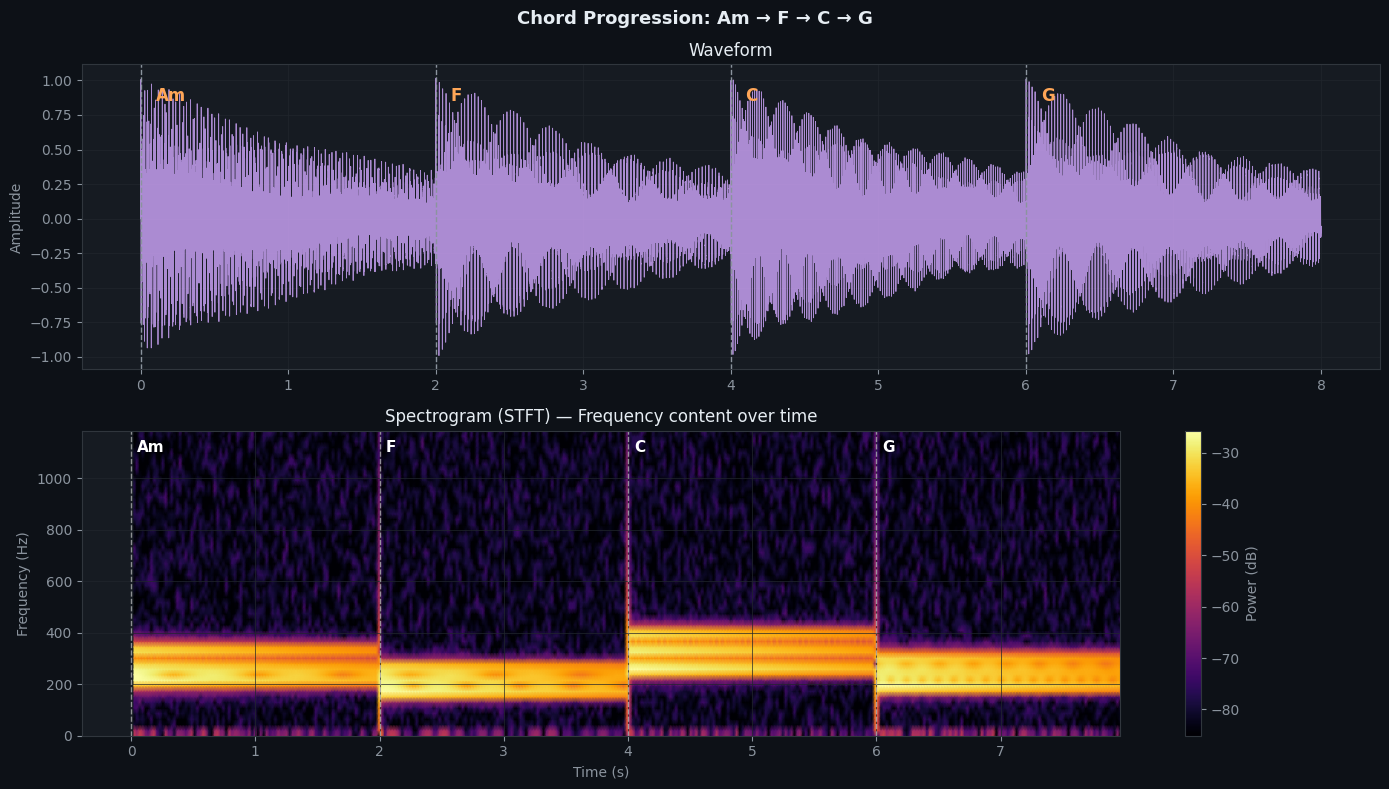

In [4]:
# Create a more interesting signal: chord progression Am -> F -> C -> G
DUR2  = 8.0
t2    = np.linspace(0, DUR2, int(FS * DUR2), endpoint=False)
beat  = DUR2 / 4  # 2 seconds per chord

CHORDS = [
    [(220.0, 1.0), (261.6, 0.8), (329.6, 0.6)],  # Am
    [(174.6, 1.0), (220.0, 0.8), (261.6, 0.6)],  # F
    [(261.6, 1.0), (329.6, 0.8), (392.0, 0.6)],  # C
    [(196.0, 1.0), (246.9, 0.8), (293.7, 0.6)],  # G
]
CHORD_NAMES = ['Am', 'F', 'C', 'G']

progression = np.zeros_like(t2)
for i, chord_notes in enumerate(CHORDS):
    start = int(i * beat * FS)
    end   = int((i+1) * beat * FS)
    t_loc = t2[start:end] - t2[start]
    for freq, amp in chord_notes:
        progression[start:end] += amp * np.sin(2*np.pi*freq*t_loc) * np.exp(-t_loc/1.8)

progression /= np.max(np.abs(progression))
progression += 0.01 * np.random.normal(0, 1, len(t2))

# Compute spectrogram
f_sg, t_sg, Sxx = signal.spectrogram(progression, fs=FS, nperseg=1024,
                                       noverlap=512, window='hann')
Sxx_db = 10 * np.log10(Sxx + 1e-10)
freq_mask = f_sg < 1200

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Chord Progression: Am → F → C → G', fontsize=13, fontweight='bold')

# Waveform
axes[0].plot(t2, progression, color=PURPLE, lw=0.6, alpha=0.8)
for i in range(4):
    axes[0].axvline(i*beat, color=MUTED, lw=1, ls='--')
    axes[0].text(i*beat + 0.1, 0.85, CHORD_NAMES[i],
                 color=ORANGE, fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform')

# Spectrogram
img = axes[1].pcolormesh(t_sg, f_sg[freq_mask], Sxx_db[freq_mask],
                          shading='gouraud', cmap='inferno',
                          vmin=np.percentile(Sxx_db[freq_mask], 20))
plt.colorbar(img, ax=axes[1], label='Power (dB)')
for i in range(4):
    axes[1].axvline(i*beat, color='white', lw=1, ls='--', alpha=0.5)
    axes[1].text(i*beat + 0.05, 1100, CHORD_NAMES[i],
                 color='white', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Spectrogram (STFT) — Frequency content over time')

plt.tight_layout()
plt.savefig('../figures/05_spectrogram.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4. Onset Detection & Tempo Estimation

Onset detection finds the moment a new note or beat starts —
equivalent to R-peak detection in ECG.
From inter-onset intervals we estimate tempo (BPM).

True BPM      : 120
Estimated BPM : 117.5


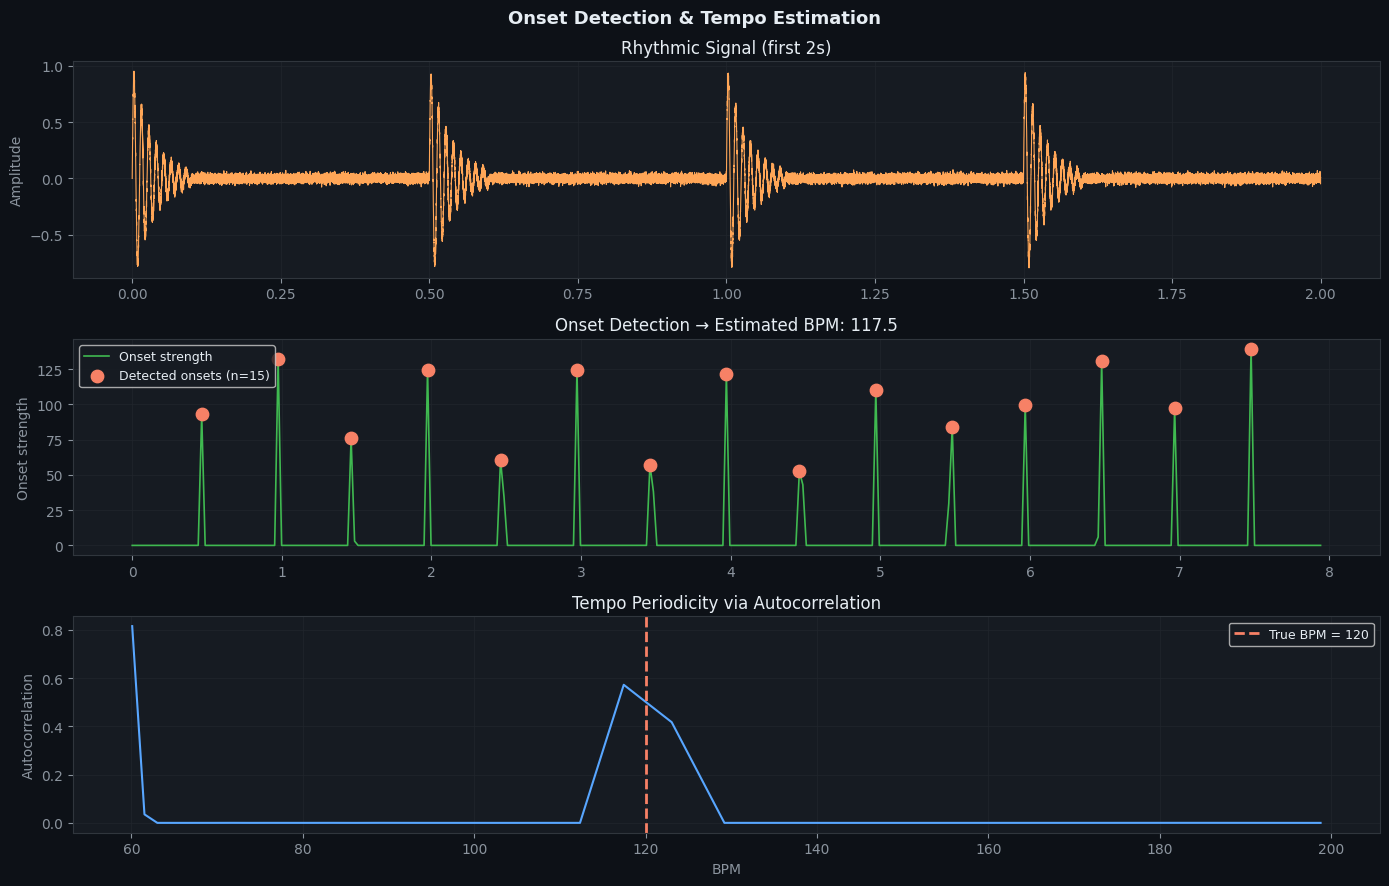

In [5]:
def onset_strength(audio, fs, hop=512):
    """Simple onset strength envelope via spectral flux."""
    # Short-time energy
    frame_len = hop
    n_frames  = len(audio) // hop
    energy    = np.array([
        np.sum(audio[i*hop:(i+1)*hop]**2)
        for i in range(n_frames)
    ])
    # Onset = positive energy increase
    onset_env = np.maximum(0, np.diff(energy))
    return onset_env

# Rhythmic signal: 120 BPM kick drum simulation
BPM_TRUE = 120
DUR3     = 8.0
t3       = np.linspace(0, DUR3, int(FS * DUR3))
beat_period = 60 / BPM_TRUE

rhythmic = np.zeros_like(t3)
for beat_t in np.arange(0, DUR3, beat_period):
    idx = int(beat_t * FS)
    if idx < len(rhythmic):
        # Kick-like transient: sharp attack + fast decay
        t_local = t3[idx:idx+int(0.1*FS)] - t3[idx]
        rhythmic[idx:idx+len(t_local)] += np.sin(2*np.pi*80*t_local) * np.exp(-t_local*30)

rhythmic += 0.02 * np.random.normal(0, 1, len(t3))

HOP = 512
onset_env = onset_strength(rhythmic, FS, hop=HOP)
onset_times = np.arange(len(onset_env)) * HOP / FS

# Detect onset peaks
min_dist = int((beat_period * 0.8 * FS) / HOP)
onset_peaks, _ = signal.find_peaks(onset_env, distance=min_dist,
                                    height=np.percentile(onset_env, 70))

# Estimate BPM from inter-onset intervals
if len(onset_peaks) > 1:
    ioi       = np.diff(onset_times[onset_peaks])  # inter-onset intervals (s)
    bpm_est   = 60 / np.median(ioi)
else:
    bpm_est = 0

print(f'True BPM      : {BPM_TRUE}')
print(f'Estimated BPM : {bpm_est:.1f}')

# Autocorrelation for tempo
max_lag = int(2.0 * FS / HOP)  # up to 2s lag
autocorr = np.correlate(onset_env, onset_env, mode='full')
autocorr = autocorr[len(autocorr)//2:][:max_lag]
autocorr /= autocorr[0]
lag_times = np.arange(len(autocorr)) * HOP / FS
lag_bpm   = np.where(lag_times > 0, 60 / lag_times, 0)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Onset Detection & Tempo Estimation', fontsize=13, fontweight='bold')

axes[0].plot(t3[:int(2*FS)], rhythmic[:int(2*FS)], color=ORANGE, lw=0.8)
axes[0].set_title('Rhythmic Signal (first 2s)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(onset_times, onset_env, color=GREEN, lw=1.2, label='Onset strength')
axes[1].scatter(onset_times[onset_peaks], onset_env[onset_peaks],
                color=RED, s=80, zorder=5, label=f'Detected onsets (n={len(onset_peaks)})')
axes[1].set_ylabel('Onset strength')
axes[1].set_title(f'Onset Detection → Estimated BPM: {bpm_est:.1f}')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

# Autocorrelation in BPM space
bpm_range = (lag_bpm > 60) & (lag_bpm < 200)
axes[2].plot(lag_bpm[bpm_range], autocorr[bpm_range], color=BLUE, lw=1.5)
axes[2].axvline(BPM_TRUE, color=RED, lw=2, ls='--', label=f'True BPM = {BPM_TRUE}')
axes[2].set_xlabel('BPM')
axes[2].set_ylabel('Autocorrelation')
axes[2].set_title('Tempo Periodicity via Autocorrelation')
axes[2].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/05_onset_tempo.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Summary

| Method | Audio use | Biosignal equivalent |
|--------|-----------|---------------------|
| FFT | Chord/note identification | HRV frequency bands (LF/HF) |
| STFT spectrogram | Chord progressions over time | EEG frequency bands over time |
| Onset detection | Beat/rhythm detection | R-peak / PPG peak detection |
| Autocorrelation | Tempo estimation | RR interval regularity |

**Key takeaway**: The same signal processing toolkit — filtering, FFT, peak detection, autocorrelation — applies seamlessly across physiological and audio signals.

➡️ **Next**: Notebook 06 — Running shoe biomechanics vs race performance (1975–2024)